# 01 · OE1 — Patrones espaciotemporales de la demanda
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.6 (análisis exploratorio) y el OE1.* **Requiere haber corrido `00_preparacion_datos`.**

In [53]:
import os
import json
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("Librerías cargadas.")

Librerías cargadas.


## 1. Carga de insumos y preparación

In [54]:
# === Raíz del repo: sirve corras desde la raíz o desde notebooks/ ===
RAIZ = os.getcwd()
if os.path.basename(RAIZ) == 'notebooks':
    RAIZ = os.path.dirname(RAIZ)
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
DATA_SOP = os.path.join(RAIZ, 'data', 'soporte')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

validaciones = pd.read_parquet(os.path.join(DATA_INT, 'validaciones_consolidadas.parquet'))
print(f'{len(validaciones):,} registros | {validaciones["estacion"].nunique()} estaciones')

# --- variables temporales (derivadas de 'fecha' para no depender del nombre exacto del 00) ---
validaciones['fecha'] = pd.to_datetime(validaciones['fecha'])
if 'hora' not in validaciones.columns:
    validaciones['hora'] = validaciones['fecha'].dt.hour
validaciones['mes'] = validaciones['fecha'].dt.month
validaciones['dow'] = validaciones['fecha'].dt.dayofweek          # 0=lunes ... 6=domingo
validaciones['anio'] = validaciones['fecha'].dt.year
validaciones['es_finde'] = (validaciones['es_fin_semana'].astype(bool)
                            if 'es_fin_semana' in validaciones.columns
                            else validaciones['dow'] >= 5)
validaciones['es_festivo'] = (validaciones['es_festivo'].astype(bool)
                              if 'es_festivo' in validaciones.columns
                              else pd.Series(False, index=validaciones.index))

# --- intervalo de 15 minutos: unidad de análisis temporal ---
# 'intervalo' viene del cuaderno 00 (hora-minuto del registro, p. ej. '06:15:00').
_iv = validaciones['intervalo']
if np.issubdtype(np.asarray(_iv).dtype, np.datetime64):
    validaciones['intervalo'] = pd.to_datetime(_iv).dt.strftime('%H:%M')
else:
    validaciones['intervalo'] = _iv.astype(str).str.slice(0, 5)
validaciones['min_dia'] = (validaciones['intervalo'].str.slice(0, 2).astype(int) * 60
                           + validaciones['intervalo'].str.slice(3, 5).astype(int))

# --- meses (solo para CONTRASTAR perfiles; NO se excluyen del análisis) ---
MESES_LECTIVOS = [2, 3, 4, 5, 8, 9, 10, 11]
MESES_RECESO   = [1, 6, 7, 12]
# --- ventana de análisis: días hábiles no festivos de TODO el periodo ---
# No se excluyen meses por receso escolar: la demanda del troncal proviene de población
# trabajadora, no estudiantil, por lo que el receso no la altera (se verifica en §4, abajo).
mask_analisis = (~validaciones['es_finde']) & (~validaciones['es_festivo'])
tipico = validaciones[mask_analisis].copy()
print(f'Ventana de análisis (días hábiles no festivos, todos los meses): {len(tipico):,} registros')

# --- paleta OFICIAL por zona ---
ZONA_COLOR = {
    'Caracas':'#00529B','Autopista Norte':'#6DB043','Suba':'#FFD100','Calle 80':'#713A84',
    'NQS Central':'#7A4B21','Américas':'#E31837','NQS Sur':'#009CDE','Caracas Sur':'#F37021',
    'Tunal':'#F37021','Eje Ambiental':'#E482AE','Calle 26':'#C49A45','Carrera 10':'#00A39F',
    'Carrera 7':'#C20078','Conector Comuneros':'#7A4B21',
}
TRAZADO_CORR = {
    'TZ001':'Caracas','TZ002':'Autopista Norte','TZ003':'Suba','TZ005':'Calle 80',
    'TZ008':'NQS Central','TZ009':'Américas','TZ010':'NQS Sur','TZ011':'NQS Sur',
    'TZ012':'Caracas Sur','TZ013':'Caracas Sur','TZ014':'Tunal','TZ015':'Eje Ambiental',
    'TZ016':'Calle 26','TZ018':'Carrera 10','TZ019':'Carrera 7','TZ007':'Conector Comuneros',
}

# --- atributos por estación (corredor + coordenadas) cruzando POR CÓDIGO: robusto ---
def z5(c): return str(c).strip().zfill(5)
est_attr = pd.DataFrame(columns=['corredor', 'lon', 'lat'])
try:
    code_to_name = json.load(open(os.path.join(DATA_SOP, 'code_to_matriz.json'), encoding='utf-8'))
    gj = json.load(open(os.path.join(DATA_SOP, 'catalogo_estaciones_troncales.geojson'), encoding='utf-8'))
    g_by_code = {z5(f['properties']['num_est']):
                 (f['properties'].get('id_trazado'),
                  float(f['properties']['longitud']), float(f['properties']['latitud']))
                 for f in gj['features']}
    filas = []
    for code, name in code_to_name.items():
        g = g_by_code.get(z5(code))
        if g:
            tz, lon, lat = g
            filas.append((name, TRAZADO_CORR.get(tz, 'Sin asignar'), lon, lat))
    est_attr = (pd.DataFrame(filas, columns=['estacion', 'corredor', 'lon', 'lat'])
                .drop_duplicates('estacion').set_index('estacion'))
    validaciones['corredor'] = validaciones['estacion'].map(est_attr['corredor']).fillna('Sin asignar')
    tipico['corredor'] = validaciones.loc[tipico.index, 'corredor']
    emp = validaciones.groupby('estacion')['corredor'].first().ne('Sin asignar').sum()
    print(f'Estaciones mapeadas a corredor (por código): {emp} de {validaciones["estacion"].nunique()}')
except FileNotFoundError:
    validaciones['corredor'] = 'Sin asignar'; tipico['corredor'] = 'Sin asignar'
    print('AVISO: faltan code_to_matriz.json o el geojson en data/soporte; se omite el análisis por corredor.')

8,192,438 registros | 148 estaciones
Ventana de análisis (días hábiles no festivos, todos los meses): 5,502,465 registros
Estaciones mapeadas a corredor (por código): 148 de 148


## 2. Calidad de los datos y valores faltantes

In [55]:
print(f"Registros consolidados: {len(validaciones):,}")
print(f"Periodo: {validaciones['fecha'].min().date()} a {validaciones['fecha'].max().date()}")
print(f"Estaciones únicas: {validaciones['estacion'].nunique()}")
print(f"Meses cubiertos: {validaciones['fecha'].dt.to_period('M').nunique()}")

print("\nValores faltantes por columna:")
print(validaciones.isna().sum().to_string())

v = validaciones['validaciones']
print(f"\nValidaciones nulas:     {v.isna().sum():,}")
print(f"Validaciones en cero:   {(v == 0).sum():,} ({(v == 0).mean()*100:.1f}%)")
print(f"Validaciones negativas: {(v < 0).sum():,}")

cobertura = validaciones.groupby('estacion')['fecha'].nunique()
print(f"\nDías-dato por estación -> min: {cobertura.min()}, "
      f"mediana: {int(cobertura.median())}, max: {cobertura.max()}")

Registros consolidados: 8,192,438
Periodo: 2024-01-01 a 2025-12-31
Estaciones únicas: 148
Meses cubiertos: 24

Valores faltantes por columna:
estacion         0
fecha            0
intervalo        0
validaciones     0
hora             0
dia_semana       0
mes              0
anio             0
es_fin_semana    0
es_festivo       0
dow              0
es_finde         0
min_dia          0
corredor         0

Validaciones nulas:     0
Validaciones en cero:   514,274 (6.3%)
Validaciones negativas: 0

Días-dato por estación -> min: 31, mediana: 731, max: 731


La cobertura temporal es desigual: aunque la mediana ronda los dos años, varias estaciones registran muchos menos días-dato. Esto refleja **operación parcial** (aperturas tardías, como Danubio) o **cierres por las obras del Metro**, no fallas de captura. Por eso los promedios se calculan únicamente sobre periodos operativos: así los cierres no se confunden con demanda genuinamente baja.

### Verificación de integridad del mapeo (control de calidad)

Antes de interpretar la demanda por estación se verifica que ningún nombre agregue varios códigos de validación distintos: una colisión de nombres **sumaría** la demanda de varias plataformas y la inflaría artificialmente (el mismo tipo de error que se corrigió en el ICP). Se revisa en particular la estación Terminal, cuya demanda resultó inesperadamente alta.

In [56]:
import json
from collections import Counter

ct = json.load(open(os.path.join(DATA_SOP, 'code_to_matriz.json'), encoding='utf-8'))
por_nombre = Counter(ct.values())
multi = {n: k for n, k in por_nombre.items() if k > 1}
print(f"Nombres que reciben más de un código de validación: {len(multi)}")
for n, k in sorted(multi.items(), key=lambda x: -x[1])[:15]:
    cods = [c for c, v in ct.items() if v == n]
    print(f"   {n!r}: {k} códigos -> {cods}")

# Foco en 'Terminal' (sospecha de demanda inflada)
dt = validaciones.groupby('estacion')['validaciones'].sum().sort_values(ascending=False)
rank = {e: i + 1 for i, e in enumerate(dt.index)}
print("\nEstaciones con 'Terminal' en el nombre:")
for e in dt.index:
    if 'terminal' in e.lower():
        print(f"   {e!r}: {dt[e]/1e6:.1f} M en demanda total  (rank #{rank[e]} de {len(dt)})")
print("\nTop-5 por demanda total (para comparar con portales reales):")
print((dt.head(5) / 1e6).round(1).to_string())

Nombres que reciben más de un código de validación: 7
   'AV. Cali': 2 códigos -> ['04003', '50004']
   'Granja - KR 77': 2 códigos -> ['04004', '04100']
   'Ricaurte': 2 códigos -> ['07111', '12003']
   'San Mateo': 2 códigos -> ['07503', '57503']
   'Portal Tunal': 2 códigos -> ['08000', '08100']
   'Molinos': 2 códigos -> ['09001', '50003']
   'AV. Jiménez': 2 códigos -> ['09110', '14003']

Estaciones con 'Terminal' en el nombre:
   'Terminal': 7.2 M en demanda total  (rank #44 de 148)

Top-5 por demanda total (para comparar con portales reales):
estacion
Portal Américas    46.0
Portal Norte       45.0
Portal Suba        35.2
Portal 80          34.8
San Mateo          34.4


## 3. Distribución de la demanda, outliers y normalidad

Justifican el uso posterior de estadística **no paramétrica** (Kruskal-Wallis) y de la mediana como medida central robusta.

Estadísticas descriptivas de las validaciones:
count    8192438.00
mean         132.61
std          254.18
min            0.00
25%           19.00
50%           59.00
75%          136.00
max         5568.00

Asimetría: 5.930 | Curtosis: 51.768
Límite superior IQR: 311.5 | 'Outliers': 827,358 (10.10%)

Shapiro-Wilk (n=5000): W=0.4748, p=3.23e-81
D'Agostino-Pearson (n=8,192,438): K2=9272438.1, p=0.00e+00


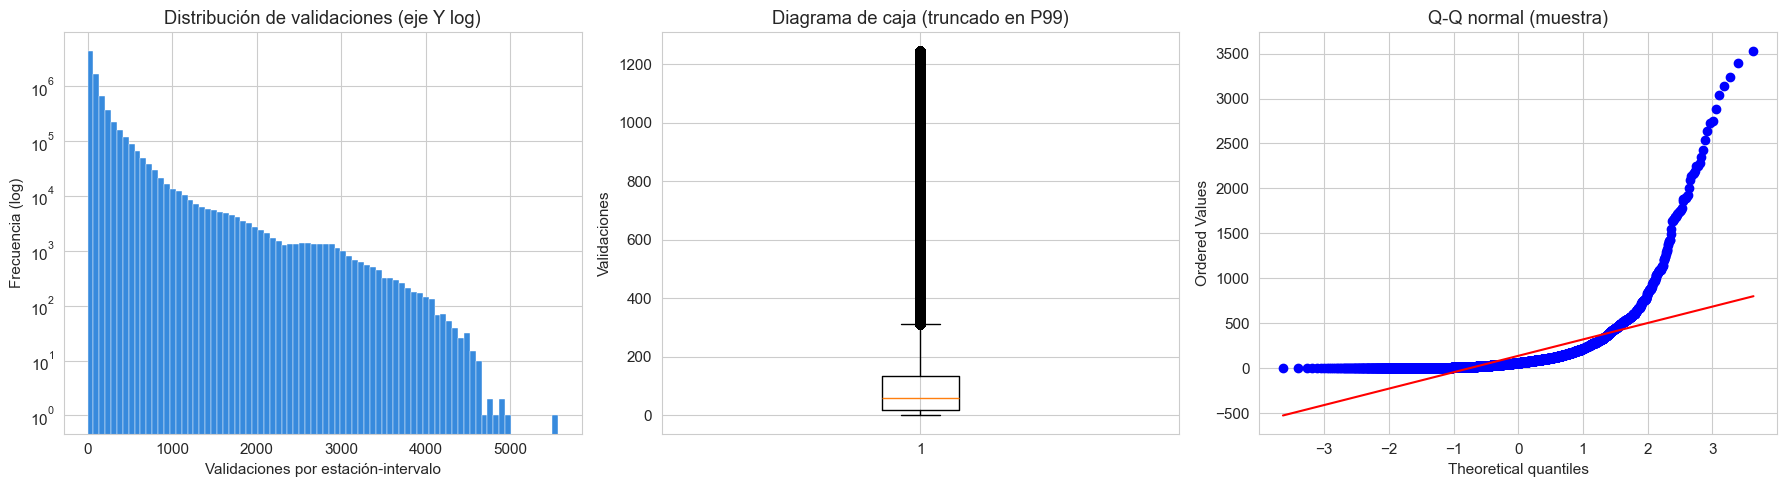

In [57]:
v = validaciones['validaciones'].dropna()
print("Estadísticas descriptivas de las validaciones:")
print(v.describe().round(2).to_string())
print(f"\nAsimetría: {v.skew():.3f} | Curtosis: {v.kurtosis():.3f}")

q1, q3 = v.quantile(.25), v.quantile(.75); iqr = q3 - q1; upper = q3 + 1.5 * iqr
n_out = (v > upper).sum()
print(f"Límite superior IQR: {upper:.1f} | 'Outliers': {n_out:,} ({n_out/len(v)*100:.2f}%)")

muestra = v.sample(n=min(5000, len(v)), random_state=42)
sh_stat, sh_p = stats.shapiro(muestra)
da_stat, da_p = stats.normaltest(v)
print(f"\nShapiro-Wilk (n={len(muestra)}): W={sh_stat:.4f}, p={sh_p:.2e}")
print(f"D'Agostino-Pearson (n={len(v):,}): K2={da_stat:.1f}, p={da_p:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(v, bins=80, color='#378ADD', edgecolor='white', linewidth=.3)
axes[0].set_yscale('log')
axes[0].set_title('Distribución de validaciones (eje Y log)')
axes[0].set_xlabel('Validaciones por estación-intervalo'); axes[0].set_ylabel('Frecuencia (log)')
axes[1].boxplot(v.clip(upper=v.quantile(.99)), vert=True)
axes[1].set_title('Diagrama de caja (truncado en P99)'); axes[1].set_ylabel('Validaciones')
stats.probplot(muestra, dist='norm', plot=axes[2]); axes[2].set_title('Q-Q normal (muestra)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_distribucion_normalidad.png'), dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.** La demanda es fuertemente asimétrica a la derecha (asimetría > 5) y ambas pruebas rechazan la normalidad (p < 0,05). **Por eso** todo el análisis emplea estadística **no paramétrica** (Kruskal-Wallis, Mann-Whitney) y la **mediana** como medida central. Los valores extremos del diagrama de caja **no son errores**: son demanda real de intervalos pico en estaciones grandes, así que **no se eliminan** —hacerlo borraría justamente los picos de saturación que el estudio busca detectar—.

### Distribución por estación individual y detección de outliers

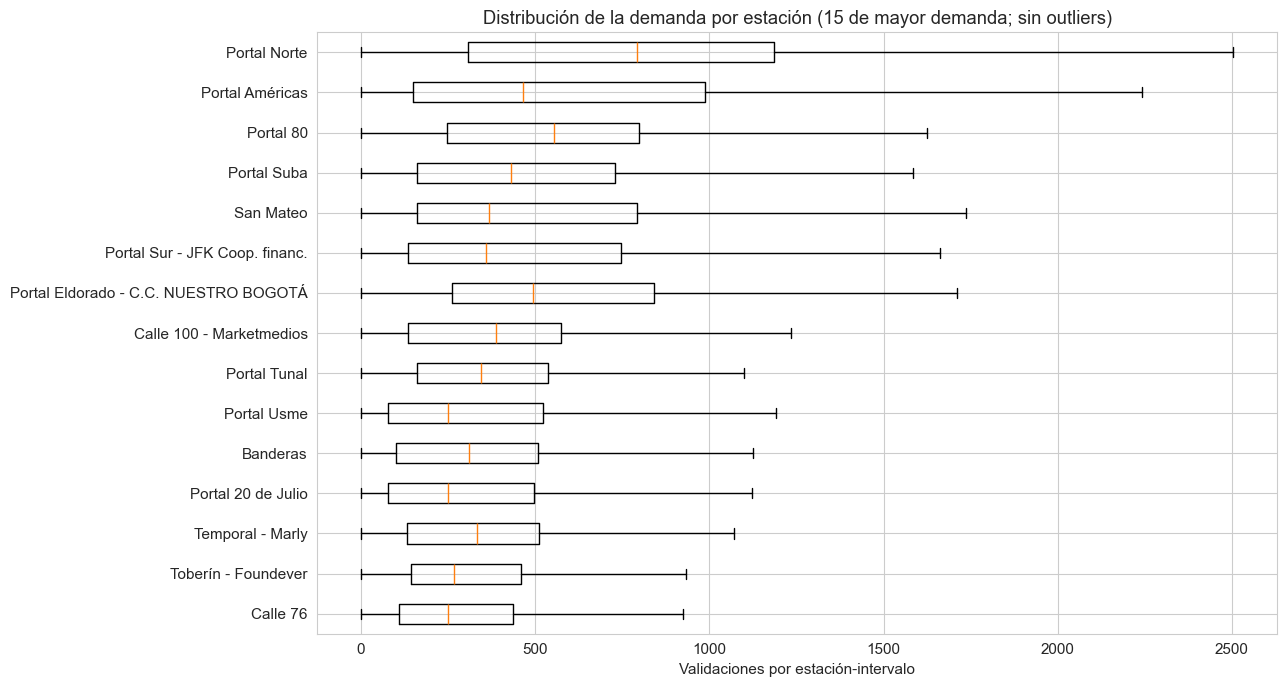

Límite de outlier (IQR): 312 validaciones/intervalo.
Estaciones con más intervalos por encima del límite IQR:
estacion
Portal Norte                             44058
Portal 80                                40311
Portal Américas                          38898
Portal Suba                              37179
Portal Eldorado - C.C. NUESTRO BOGOTÁ    35634
San Mateo                                33375
Portal Sur - JFK Coop. financ.           32170
Portal Tunal                             31890
Calle 100 - Marketmedios                 24836
AV. Jiménez                              24652


In [58]:
# Distribución de la demanda por estación (15 de mayor demanda) + outliers por estación
orden = tipico.groupby('estacion')['validaciones'].mean().sort_values(ascending=False).head(15).index[::-1]
datos = [tipico.loc[tipico['estacion'] == e, 'validaciones'].values for e in orden]
fig, ax = plt.subplots(figsize=(13, 7))
ax.boxplot(datos, vert=False, showfliers=False)
ax.set_yticks(range(1, len(orden) + 1)); ax.set_yticklabels(orden)
ax.set_xlabel('Validaciones por estación-intervalo')
ax.set_title('Distribución de la demanda por estación (15 de mayor demanda; sin outliers)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_distribucion_por_estacion.png'), dpi=150, bbox_inches='tight'); plt.show()

# ¿Qué estaciones concentran los intervalos atípicos? Se conservan: son demanda pico real, no ruido
q1, q3 = validaciones['validaciones'].quantile([.25, .75])
lim = q3 + 1.5 * (q3 - q1)
out_est = validaciones[validaciones['validaciones'] > lim].groupby('estacion').size().sort_values(ascending=False)
print(f"Límite de outlier (IQR): {lim:.0f} validaciones/intervalo.")
print("Estaciones con más intervalos por encima del límite IQR:")
print(out_est.head(10).to_string())

Los intervalos atípicos **no se distribuyen al azar**: se concentran en las estaciones de mayor demanda (portales y grandes intercambiadores en hora pico). Esto confirma que son **picos legítimos** y no ruido, y refuerza la decisión de conservarlos.

## 4. Correlaciones entre variables

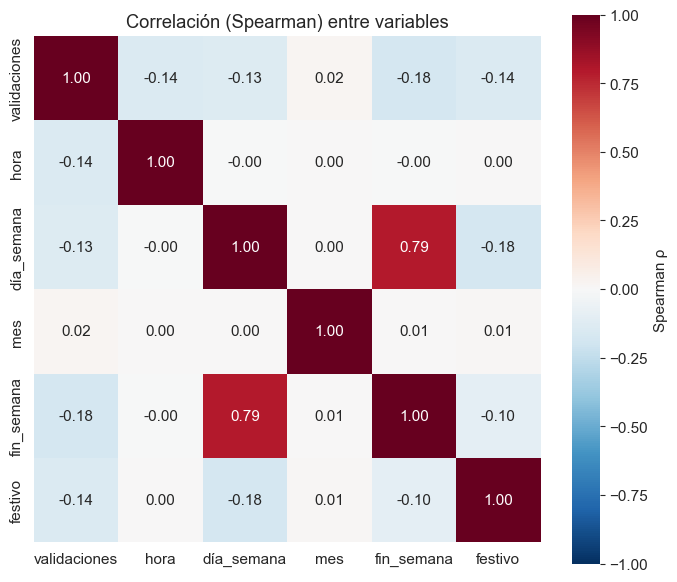

In [59]:
# Matriz de correlación de Spearman (no paramétrica, dada la no normalidad)
cols = ['validaciones', 'hora', 'dow', 'mes']
sub = validaciones[cols].copy()
for b in ['es_fin_semana', 'es_festivo']:
    if b in validaciones.columns:
        sub[b] = validaciones[b].astype(int)
# Spearman (no Pearson): las variables no son normales (ver §3); capta relación monótona, no lineal
sub = sub.rename(columns={'dow': 'día_semana', 'es_fin_semana': 'fin_semana', 'es_festivo': 'festivo'})
corr = sub.sample(n=min(200000, len(sub)), random_state=42).corr(method='spearman')
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Spearman \u03c1'}, ax=ax)
ax.set_title('Correlación (Spearman) entre variables')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_correlaciones.png'), dpi=150, bbox_inches='tight'); plt.show()

Se usa **Spearman** (no Pearson) por la no normalidad de las variables. Las correlaciones lineales con la demanda son **débiles** (|ρ| < 0,2): ninguna variable temporal por sí sola la explica, sino su **interacción** (hora × tipo de día × estación). Esto **justifica** el modelo no lineal de OE5. La correlación alta entre `día_semana` y `fin_semana` (ρ ≈ 0,79) es esperada, el indicador se deriva del día y advierte que no conviene usar ambas como predictores a la vez por redundancia.

## 5. Patrones temporales y estacionalidad

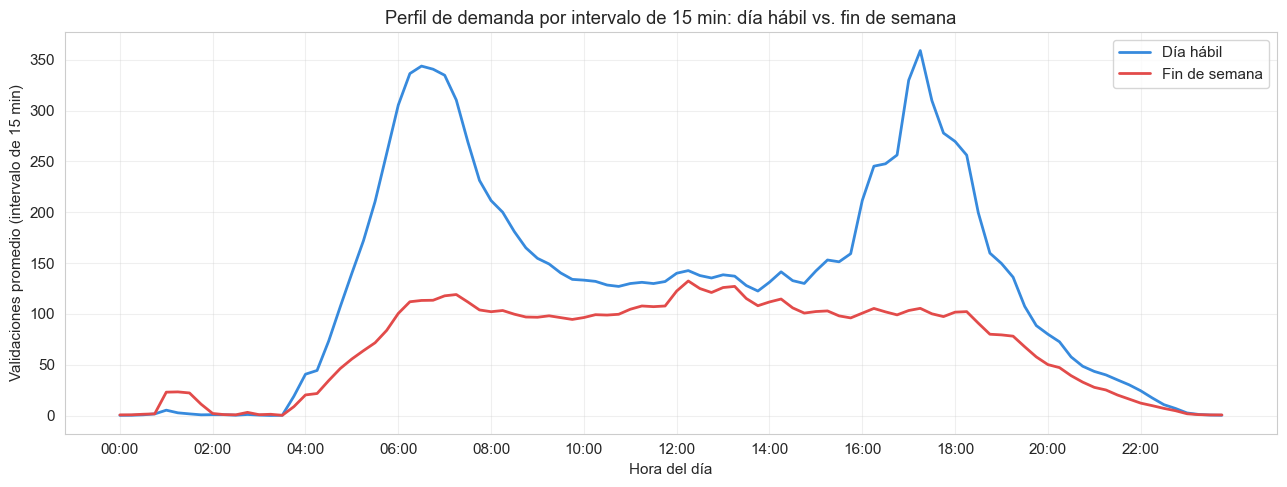

Pico AM: 06:30 (344) | Pico PM: 17:15 (359) | razón pico/mediodía: 2.9x


In [60]:
# --- perfil por intervalo de 15 min: día hábil vs. fin de semana ---
perfil = validaciones.groupby(['es_finde', 'intervalo'])['validaciones'].mean().reset_index()
perfil['min_dia'] = perfil['intervalo'].str.slice(0, 2).astype(int) * 60 + perfil['intervalo'].str.slice(3, 5).astype(int)
perfil = perfil.sort_values('min_dia')
fig, ax = plt.subplots(figsize=(13, 5))
for fds, etq, c in [(False, 'Día hábil', '#378ADD'), (True, 'Fin de semana', '#E24B4A')]:
    d = perfil[perfil['es_finde'] == fds]
    ax.plot(d['min_dia'], d['validaciones'], label=etq, color=c, linewidth=2)
ax.set_xlabel('Hora del día'); ax.set_ylabel('Validaciones promedio (intervalo de 15 min)')
ax.set_xticks(range(0, 24 * 60, 120)); ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax.set_title('Perfil de demanda por intervalo de 15 min: día hábil vs. fin de semana')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_perfil_horario.png'), dpi=150, bbox_inches='tight'); plt.show()

# Picos por intervalo y razón pico/mediodía
hm = perfil[perfil['es_finde'] == False].set_index('min_dia')['validaciones']
am = hm[(hm.index >= 5 * 60) & (hm.index <= 9 * 60)]
pm = hm[(hm.index >= 16 * 60) & (hm.index <= 20 * 60)]
md = hm[(hm.index >= 10 * 60) & (hm.index <= 15 * 60)]
def _lbl(m): return f'{m // 60:02d}:{m % 60:02d}'
print(f"Pico AM: {_lbl(int(am.idxmax()))} ({am.max():.0f}) | "
      f"Pico PM: {_lbl(int(pm.idxmax()))} ({pm.max():.0f}) | "
      f"razón pico/mediodía: {max(am.max(), pm.max()) / md.min():.1f}x")


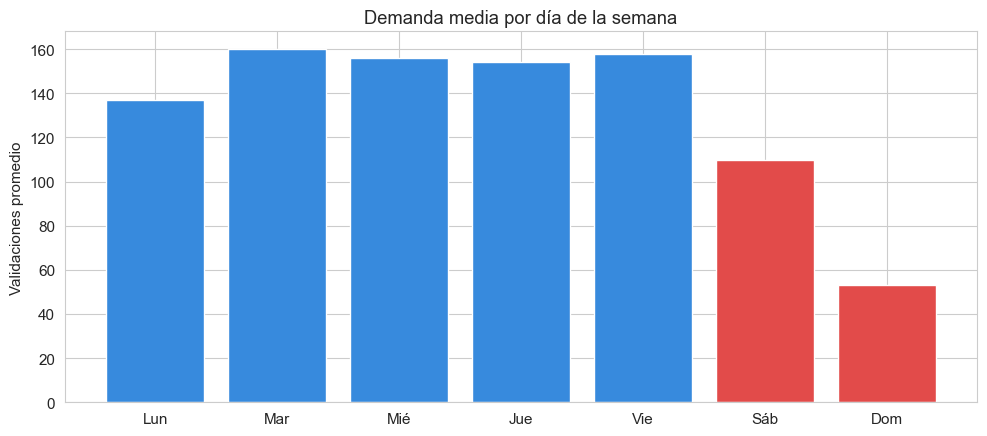

In [61]:
# --- perfil por día de la semana ---
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
pdow = validaciones.groupby('dow')['validaciones'].mean()
cols = ['#378ADD'] * 5 + ['#E24B4A'] * 2
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar([dias[i] for i in pdow.index], pdow.values, color=[cols[i] for i in pdow.index], edgecolor='white')
ax.set_ylabel('Validaciones promedio'); ax.set_title('Demanda media por día de la semana')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_perfil_dia_semana.png'), dpi=150, bbox_inches='tight'); plt.show()

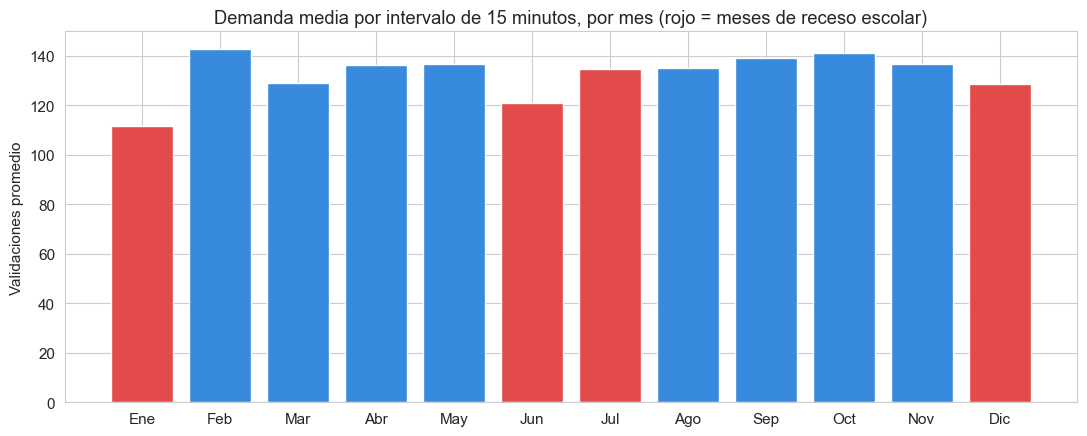

Rango de la demanda media por estación-intervalo entre meses: 112-143 validaciones.


In [62]:
# --- perfil mensual ---
meses_lbl = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
pmes = validaciones.groupby('mes')['validaciones'].mean()
cols = ['#E24B4A' if m in MESES_RECESO else '#378ADD' for m in pmes.index]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar([meses_lbl[m] for m in pmes.index], pmes.values, color=cols, edgecolor='white')
ax.set_ylabel('Validaciones promedio')
ax.set_title('Demanda media por intervalo de 15 minutos, por mes (rojo = meses de receso escolar)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_perfil_mensual.png'), dpi=150, bbox_inches='tight'); plt.show()

print(f"Rango de la demanda media por estación-intervalo entre meses: {pmes.min():.0f}-{pmes.max():.0f} validaciones.")

**Decisión metodológica.** La magnitud media por intervalo es estable entre meses; solo enero cae con claridad (vacaciones colectivas de fin de año, que sí afectan a adultos). Junio, julio y diciembre son comparables a los meses lectivos. **Por eso no se excluyen meses por receso escolar**: la demanda del troncal proviene de población trabajadora, no estudiantil. Se analizan **todos los días hábiles no festivos**, lo que duplica los datos; la comparación de la forma del perfil (abajo) confirma esta decisión.

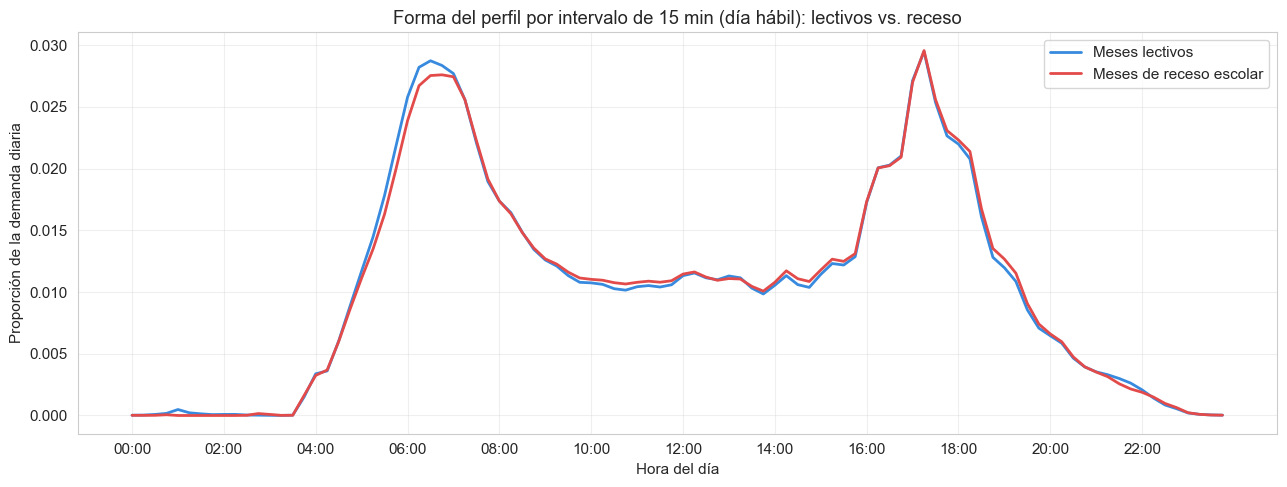

Concentración en el pico AM (6:00-8:59): lectivos=0.268 vs. receso=0.262 (dif=+0.005).


In [63]:
# --- forma del perfil por intervalo de 15 min: meses lectivos vs. receso ---
habiles = validaciones[~validaciones['es_finde'] & ~validaciones['es_festivo']]
def _forma(msel):
    s = habiles[habiles['mes'].isin(msel)].groupby('intervalo')['validaciones'].mean()
    return s / s.sum()
fn, fv = _forma(MESES_LECTIVOS), _forma(MESES_RECESO)
ix = sorted(set(fn.index) | set(fv.index), key=lambda t: int(t[:2]) * 60 + int(t[3:5]))
xm = [int(t[:2]) * 60 + int(t[3:5]) for t in ix]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(xm, fn.reindex(ix).values, label='Meses lectivos', color='#378ADD', linewidth=2)
ax.plot(xm, fv.reindex(ix).values, label='Meses de receso escolar', color='#E24B4A', linewidth=2)
ax.set_xlabel('Hora del día'); ax.set_ylabel('Proporción de la demanda diaria')
ax.set_xticks(range(0, 24 * 60, 120)); ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax.set_title('Forma del perfil por intervalo de 15 min (día hábil): lectivos vs. receso')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_perfil_lectivo_vs_vacaciones.png'), dpi=150, bbox_inches='tight'); plt.show()

# Concentración en el pico AM (6:00-8:59), sumando los intervalos de esas horas
def _am(s): return s[[t for t in s.index if 6 <= int(t[:2]) <= 8]].sum()
am_lect, am_rec = _am(fn), _am(fv)
print(f"Concentración en el pico AM (6:00-8:59): lectivos={am_lect:.3f} vs. receso={am_rec:.3f} "
      f"(dif={am_lect - am_rec:+.3f}).")


**Confirmación empírica.** Al normalizar cada perfil a su forma (proporción de la demanda diaria por hora), los meses lectivos y de receso resultan **prácticamente idénticos** en la concentración del pico de la mañana. El receso escolar no altera el patrón temporal de la demanda del troncal, lo que **respalda no filtrar por mes**.

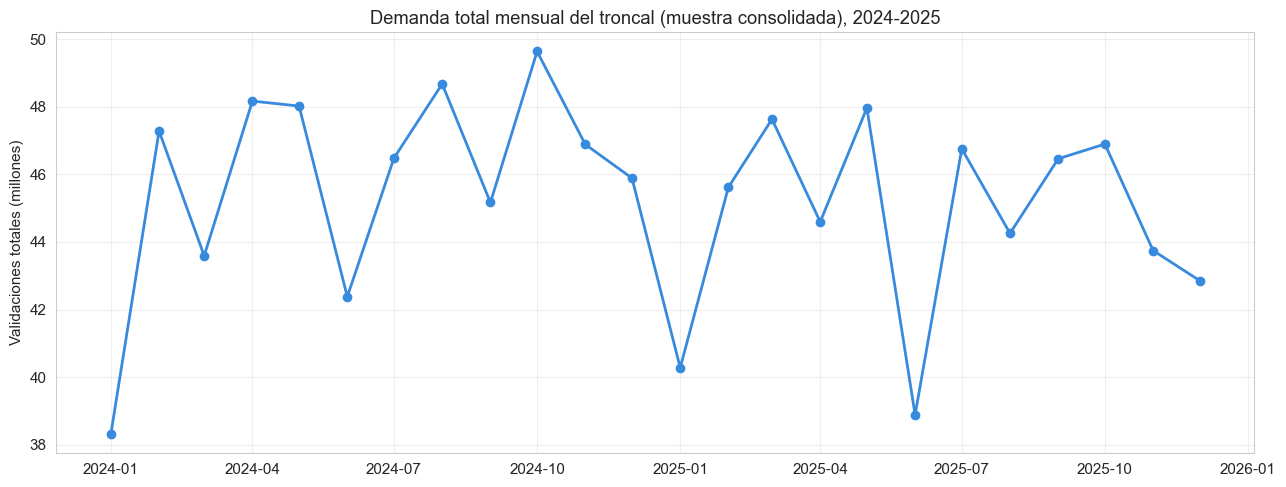

Total 2024: 550.5 M | Total 2025: 535.9 M | variación interanual: -2.6%


In [64]:
# --- serie mensual de demanda 2024-2025 (tendencia y variación interanual) ---
serie = validaciones.groupby(validaciones['fecha'].dt.to_period('M'))['validaciones'].sum()
serie.index = serie.index.to_timestamp()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie.index, serie.values / 1e6, marker='o', color='#378ADD', linewidth=2)
ax.set_ylabel('Validaciones totales (millones)')
ax.set_title('Demanda total mensual del troncal (muestra consolidada), 2024-2025')
ax.grid(alpha=.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_serie_mensual.png'), dpi=150, bbox_inches='tight'); plt.show()

tot24 = validaciones.loc[validaciones['fecha'].dt.year == 2024, 'validaciones'].sum()
tot25 = validaciones.loc[validaciones['fecha'].dt.year == 2025, 'validaciones'].sum()
print(f"Total 2024: {tot24/1e6:.1f} M | Total 2025: {tot25/1e6:.1f} M | "
      f"variación interanual: {(tot25/tot24-1)*100:+.1f}%")

## 6. Comparación interanual 2024–2025 y efecto de las obras del Metro

El planteamiento del problema identifica las obras de la Primera Línea del Metro (PLMB) como factor coyuntural. Esta sección contrasta 2024 y 2025 para dimensionar su efecto.

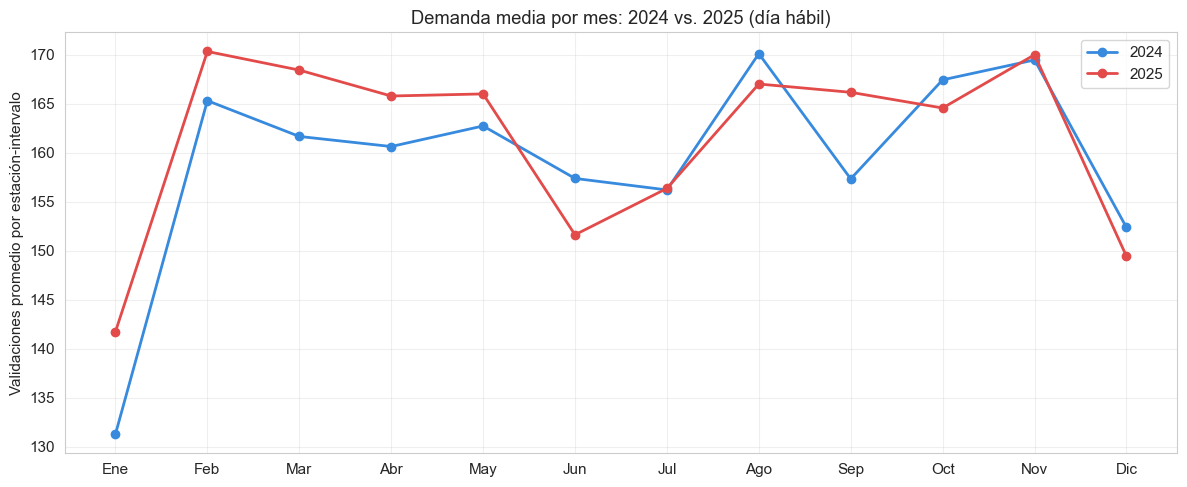

Demanda total 2024: 550.5 M | 2025: 535.9 M | variación: -2.6%


In [65]:
# Demanda media por mes: 2024 vs. 2025 (días hábiles no festivos)
piv_m = tipico.pivot_table(index='mes', columns='anio', values='validaciones', aggfunc='mean')
meses_lbl = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
fig, ax = plt.subplots(figsize=(12, 5))
for y, c in [(2024, '#378ADD'), (2025, '#E24B4A')]:
    if y in piv_m.columns:
        ax.plot([meses_lbl[m] for m in piv_m.index], piv_m[y], marker='o', label=str(y), color=c, linewidth=2)
ax.set_ylabel('Validaciones promedio por estación-intervalo')
ax.set_title('Demanda media por mes: 2024 vs. 2025 (día hábil)'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_mensual_2024_vs_2025.png'), dpi=150, bbox_inches='tight'); plt.show()

tot24 = validaciones.loc[validaciones['anio'] == 2024, 'validaciones'].sum()
tot25 = validaciones.loc[validaciones['anio'] == 2025, 'validaciones'].sum()
print(f"Demanda total 2024: {tot24/1e6:.1f} M | 2025: {tot25/1e6:.1f} M | variación: {(tot25/tot24-1)*100:+.1f}%")

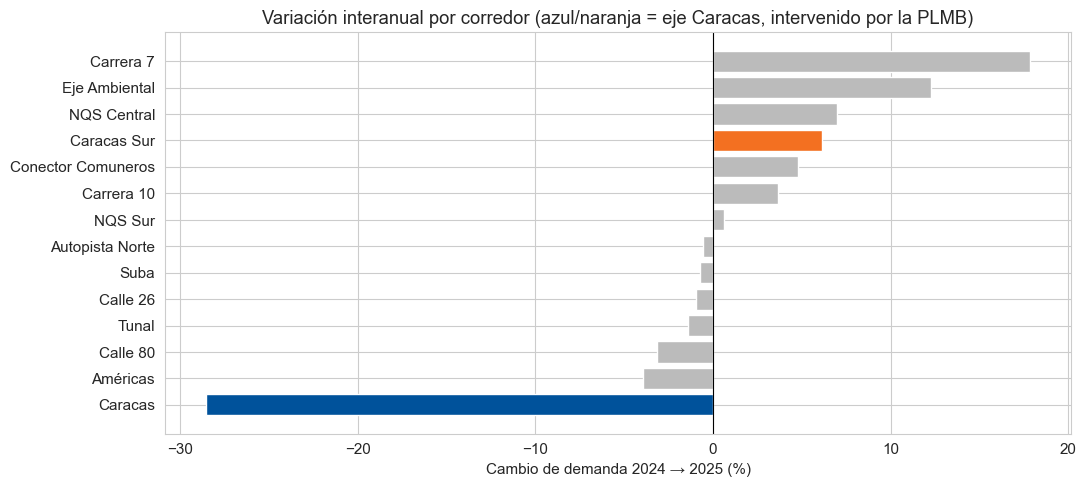

corredor
Caracas              -28.5
Américas              -3.9
Calle 80              -3.1
Tunal                 -1.4
Calle 26              -0.9
Suba                  -0.7
Autopista Norte       -0.6
NQS Sur                0.6
Carrera 10             3.7
Conector Comuneros     4.8
Caracas Sur            6.1
NQS Central            7.0
Eje Ambiental         12.3
Carrera 7             17.8


In [66]:
# Variación interanual por corredor: el eje Caracas concentra el efecto de las obras del Metro
if (validaciones['corredor'] != 'Sin asignar').any():
    hab2 = validaciones[(~validaciones['es_finde']) & (~validaciones['es_festivo'])
                        & (validaciones['corredor'] != 'Sin asignar')]
    py = hab2.pivot_table(index='corredor', columns='anio', values='validaciones', aggfunc='sum')
    if {2024, 2025}.issubset(py.columns):
        py['cambio_%'] = (py[2025] / py[2024] - 1) * 100
        py = py.sort_values('cambio_%')
        cor = ['#00529B' if c == 'Caracas' else ('#F37021' if c == 'Caracas Sur' else '#BBBBBB') for c in py.index]
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.barh(py.index, py['cambio_%'], color=cor, edgecolor='white'); ax.axvline(0, color='black', lw=.8)
        ax.set_xlabel('Cambio de demanda 2024 \u2192 2025 (%)')
        ax.set_title('Variación interanual por corredor (azul/naranja = eje Caracas, intervenido por la PLMB)')
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_cambio_corredor_2024_2025.png'), dpi=150, bbox_inches='tight'); plt.show()
        print(py['cambio_%'].round(1).to_string())
    else:
        print('No están ambos años en el dato; se omite.')
else:
    print('Sin mapeo de corredor; se omite.')

In [67]:
# Estaciones del eje Caracas con mayor caída interanual (cierres/provisionales por la PLMB)
car = validaciones[validaciones['corredor'].isin(['Caracas', 'Caracas Sur'])]
ps = car.pivot_table(index='estacion', columns='anio', values='validaciones', aggfunc='sum').dropna()
if {2024, 2025}.issubset(ps.columns):
    ps['cambio_%'] = (ps[2025] / ps[2024] - 1) * 100
    print('Estaciones del eje Caracas con mayor caída interanual (efecto de las obras del Metro):')
    print(ps.sort_values('cambio_%').head(10)['cambio_%'].round(1).to_string())
else:
    print('No están ambos años; se omite.')

Estaciones del eje Caracas con mayor caída interanual (efecto de las obras del Metro):
estacion
Calle 26              -99.4
Calle 19              -84.1
Tercer Milenio        -77.7
Consuelo              -54.0
Temporal - Calle 34   -49.2
AV. 39                -43.9
Hospital              -21.3
Temporal - Calle 57   -16.3
Quiroga                -9.5
Santa Lucía            -8.1


**Hallazgo — factor coyuntural.** Las caídas más pronunciadas del eje Caracas entre 2024 y 2025 corresponden a las estaciones **cerradas o vueltas provisionales por las obras de la Primera Línea del Metro** (Tercer Milenio, Calle 19, Calle 26, AV. 39, Calle 63, Calle 72, Hospital…). Esto dimensiona el factor coyuntural del planteamiento: la intervención del Metro reconfigura la demanda del corredor más importante del sistema y debe tenerse presente al interpretar el ICP/IPD de esas estaciones.

## 7. Patrones espaciales de la demanda

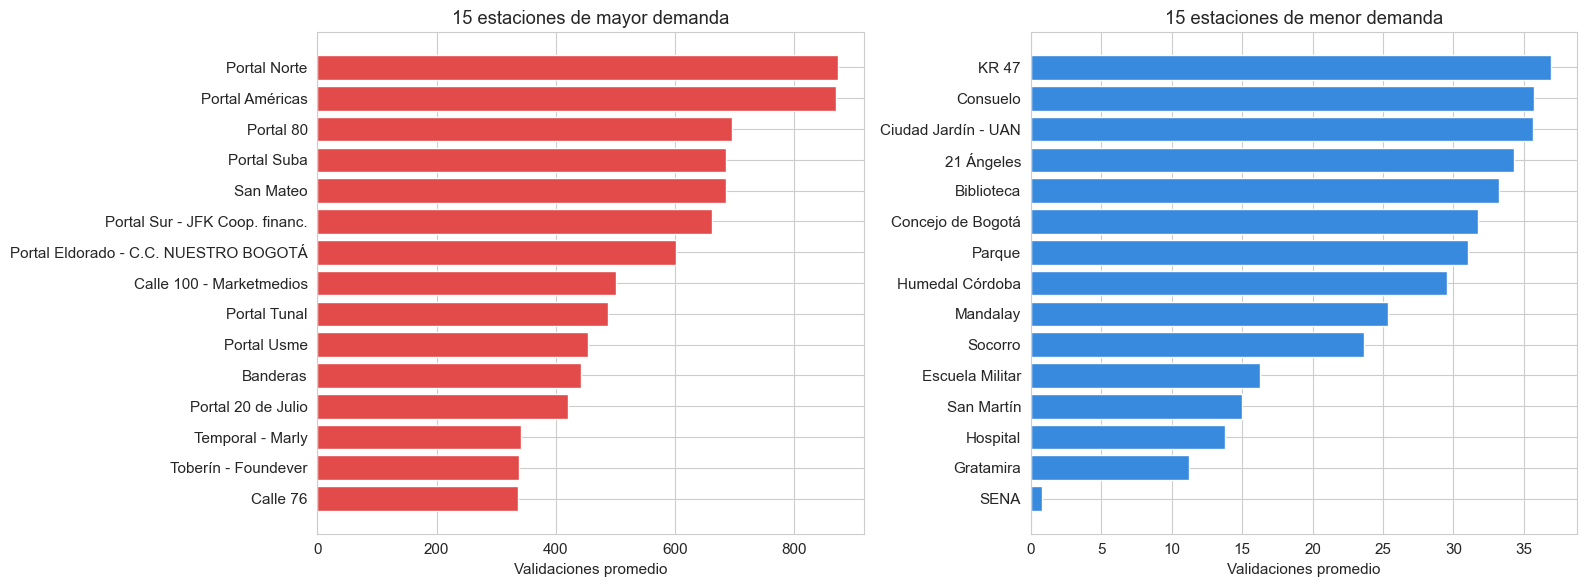

Tabla guardada: oe1_demanda_por_estacion.csv (148 estaciones)


In [68]:
# --- estaciones de mayor y menor demanda (ventana típica) ---
dem_est = tipico.groupby('estacion')['validaciones'].mean().sort_values(ascending=False)
top, bottom = dem_est.head(15), dem_est.tail(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top.index[::-1], top.values[::-1], color='#E24B4A', edgecolor='white')
axes[0].set_title('15 estaciones de mayor demanda'); axes[0].set_xlabel('Validaciones promedio')
axes[1].barh(bottom.index[::-1], bottom.values[::-1], color='#378ADD', edgecolor='white')
axes[1].set_title('15 estaciones de menor demanda'); axes[1].set_xlabel('Validaciones promedio')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_estaciones_top_bottom.png'), dpi=150, bbox_inches='tight'); plt.show()

dem_est.round(2).to_csv(os.path.join(OUT_TAB, 'oe1_demanda_por_estacion.csv'))
print(f"Tabla guardada: oe1_demanda_por_estacion.csv ({len(dem_est)} estaciones)")

### Estaciones de mayor demanda: total diario y en hora pico

Complementa el ranking anterior con la demanda media por **día hábil** y su desglose en los picos de la mañana y de la tarde, separando portales de estaciones no terminales. Usa `tipico` (días hábiles no festivos) con los códigos **ya unificados** por estación.

In [69]:
# --- estaciones de mayor demanda: total por día hábil y en hora pico ---
PICO_AM, PICO_PM = 6, 17   # horas pico identificadas en el perfil (4.1.3)
diario = tipico.groupby(['estacion', 'fecha'])['validaciones'].sum()
val_dia = diario.groupby('estacion').mean()
def _pico(h):
    return (tipico[tipico['hora'] == h]
            .groupby(['estacion', 'fecha'])['validaciones'].sum()
            .groupby('estacion').mean())
dem_pico = (pd.DataFrame({'val_dia': val_dia, 'pico_manana': _pico(PICO_AM), 'pico_tarde': _pico(PICO_PM)})
            .round(0).sort_values('val_dia', ascending=False))
es_portal = dem_pico.index.to_series().str.contains('Portal|Cabecera|Terminal', case=False, regex=True)

print('TOP PORTALES por demanda de día hábil:')
print(dem_pico[es_portal].head(10).to_string())
print('\nTOP ESTACIONES (no portal) por demanda de día hábil:')
print(dem_pico[~es_portal].head(10).to_string())

dem_pico.to_csv(os.path.join(OUT_TAB, 'oe1_demanda_pico_estacion.csv'))
print('\nTabla guardada: oe1_demanda_pico_estacion.csv')

TOP PORTALES por demanda de día hábil:
                                       val_dia  pico_manana  pico_tarde
estacion                                                               
Portal Américas                        74005.0      14319.0      1539.0
Portal Norte                           71398.0       9387.0      5490.0
Portal Suba                            56786.0      11707.0      1876.0
Portal 80                              56256.0       9169.0      2774.0
Portal Sur - JFK Coop. financ.         54274.0      11550.0      1283.0
Portal Eldorado - C.C. NUESTRO BOGOTÁ  49110.0       6011.0      5723.0
Portal Tunal                           42275.0       7443.0      1522.0
Portal Usme                            38034.0       7917.0       854.0
Portal 20 de Julio                     34514.0       6775.0       865.0
Terminal                               12324.0       1825.0       960.0

TOP ESTACIONES (no portal) por demanda de día hábil:
                          val_dia  pico_man

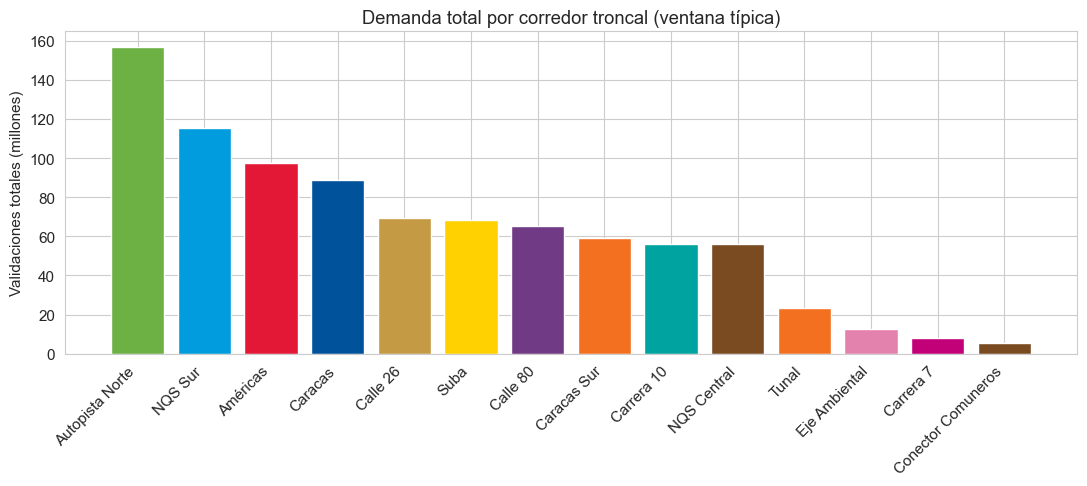

corredor
Autopista Norte       156.89
NQS Sur               115.37
Américas               97.40
Caracas                88.77
Calle 26               69.17
Suba                   68.09
Calle 80               65.09
Caracas Sur            59.22
Carrera 10             56.27
NQS Central            55.87
Tunal                  23.32
Eje Ambiental          12.84
Carrera 7               7.98
Conector Comuneros      5.36


In [70]:
# --- demanda TOTAL por corredor (paleta oficial por zona) ---
if (tipico['corredor'] != 'Sin asignar').any():
    dem_corr = tipico[tipico['corredor'] != 'Sin asignar'].groupby('corredor')['validaciones'].sum()
    dem_corr = dem_corr.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(dem_corr.index, dem_corr.values / 1e6,
           color=[ZONA_COLOR.get(c, '#999999') for c in dem_corr.index], edgecolor='white')
    ax.set_ylabel('Validaciones totales (millones)')
    ax.set_title('Demanda total por corredor troncal (ventana típica)')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_demanda_por_corredor.png'), dpi=150, bbox_inches='tight'); plt.show()
    print((dem_corr / 1e6).round(2).to_string())
else:
    print('Sin mapeo de corredor disponible; se omite esta figura.')

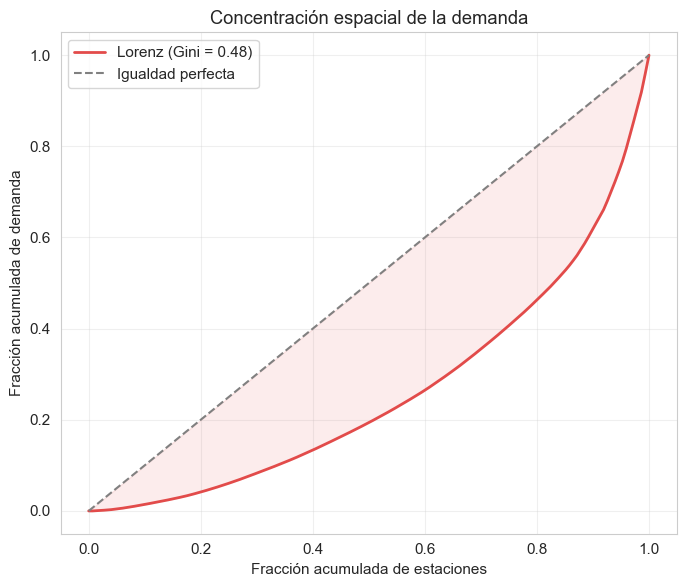

Gini = 0.48. El 10% de estaciones de mayor demanda concentra el 37% del total; el 20%, el 53%.


In [71]:
# --- concentración espacial de la demanda (curva de Lorenz + Gini) ---
dem_tot = tipico.groupby('estacion')['validaciones'].sum()
d = np.sort(dem_tot.values)
cum = np.concatenate([[0], np.cumsum(d) / d.sum()])
x = np.linspace(0, 1, len(d) + 1)
gini = 1 - 2 * np.trapz(cum, x)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x, cum, color='#E24B4A', linewidth=2, label=f'Lorenz (Gini = {gini:.2f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Igualdad perfecta')
ax.fill_between(x, x, cum, color='#E24B4A', alpha=.1)
ax.set_xlabel('Fracción acumulada de estaciones'); ax.set_ylabel('Fracción acumulada de demanda')
ax.set_title('Concentración espacial de la demanda'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_concentracion_lorenz.png'), dpi=150, bbox_inches='tight'); plt.show()

orden = dem_tot.sort_values(ascending=False)
top10 = orden.head(max(1, int(len(orden)*.10))).sum() / orden.sum()
top20 = orden.head(max(1, int(len(orden)*.20))).sum() / orden.sum()
print(f"Gini = {gini:.2f}. El 10% de estaciones de mayor demanda concentra el {top10*100:.0f}% del total; "
      f"el 20%, el {top20*100:.0f}%.")

## 8. Patrón espaciotemporal: estación × hora

El corazón de OE1. Revela **qué** estaciones concentran su demanda **cuándo**: estaciones de *origen* (pico de mañana, residenciales) frente a estaciones de *destino* (pico de tarde, de empleo/servicios).

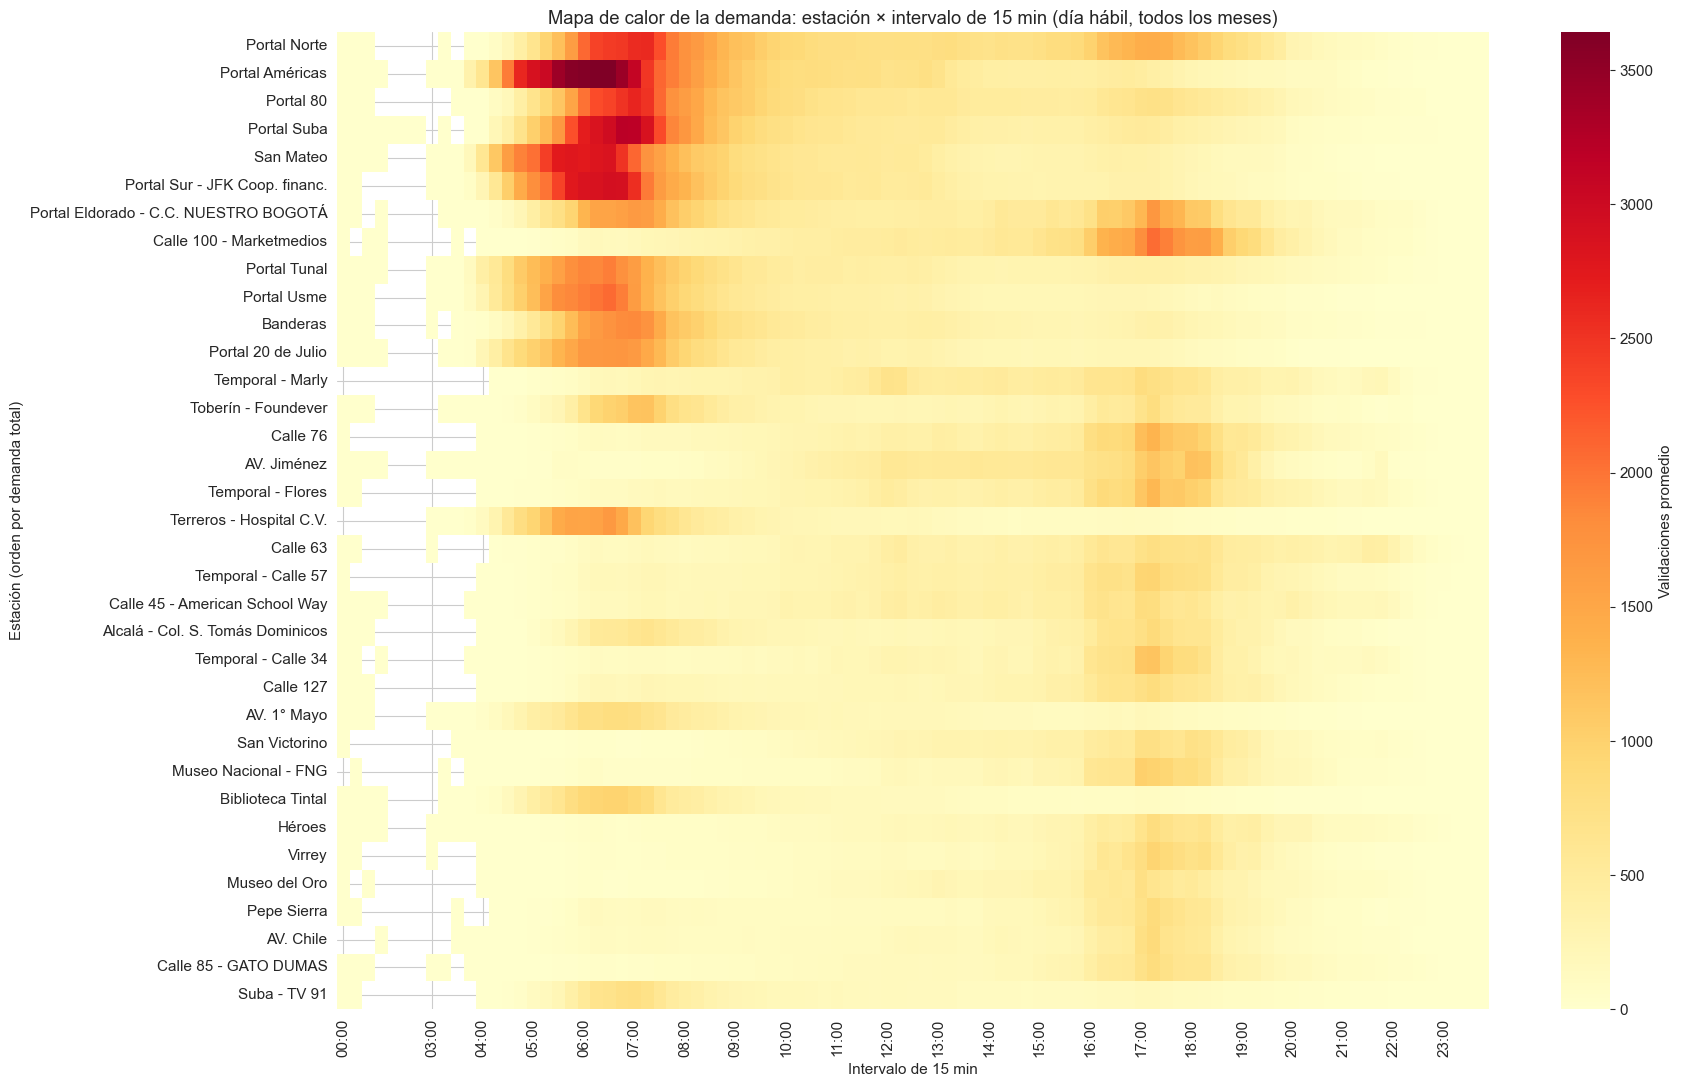

In [72]:
# --- mapa de calor estación x intervalo de 15 min (top 35 por demanda) ---
top_est = tipico.groupby('estacion')['validaciones'].mean().sort_values(ascending=False).head(35).index
piv = (tipico[tipico['estacion'].isin(top_est)]
       .groupby(['estacion', 'intervalo'])['validaciones'].mean()
       .unstack('intervalo').reindex(top_est))
piv = piv[sorted(piv.columns, key=lambda t: int(t[:2]) * 60 + int(t[3:5]))]
fig, ax = plt.subplots(figsize=(18, 11))
sns.heatmap(piv, cmap='YlOrRd', cbar_kws={'label': 'Validaciones promedio'}, ax=ax)
xt = [i for i, t in enumerate(piv.columns) if t[3:5] == '00']   # solo etiquetas en hora en punto
ax.set_xticks([i + 0.5 for i in xt]); ax.set_xticklabels([piv.columns[i] for i in xt], rotation=90)
ax.set_title('Mapa de calor de la demanda: estación × intervalo de 15 min (día hábil, todos los meses)')
ax.set_xlabel('Intervalo de 15 min'); ax.set_ylabel('Estación (orden por demanda total)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_heatmap_estacion_hora.png'), dpi=150, bbox_inches='tight'); plt.show()


In [73]:
# --- clasificación de estaciones por momento del pico (origen vs destino), por intervalo ---
ph = tipico.groupby(['estacion', 'intervalo'])['validaciones'].mean().unstack('intervalo').fillna(0)
total = ph.sum(axis=1).replace(0, np.nan)
am_cols = [t for t in ph.columns if 6 <= int(t[:2]) <= 8]    # intervalos del pico AM (6:00-8:59)
pm_cols = [t for t in ph.columns if 16 <= int(t[:2]) <= 18]   # intervalos del pico PM (16:00-18:59)
am_share = ph[am_cols].sum(axis=1) / total
pm_share = ph[pm_cols].sum(axis=1) / total
perfil_pico = pd.DataFrame({'am_share': am_share, 'pm_share': pm_share})
perfil_pico['perfil'] = np.where(am_share - pm_share > 0.05, 'Origen (pico AM)',
                         np.where(pm_share - am_share > 0.05, 'Destino (pico PM)', 'Mixto / plano'))

print('Estaciones por perfil de pico:')
print(perfil_pico['perfil'].value_counts().to_string())
print('\nMás marcadas de ORIGEN (concentración matinal):')
print((am_share - pm_share).sort_values(ascending=False).head(8).round(3).to_string())
print('\nMás marcadas de DESTINO (concentración vespertina):')
print((pm_share - am_share).sort_values(ascending=False).head(8).round(3).to_string())

perfil_pico.round(3).to_csv(os.path.join(OUT_TAB, 'oe1_perfil_pico_estacion.csv'))
print('\nTabla guardada: oe1_perfil_pico_estacion.csv')


Estaciones por perfil de pico:
perfil
Destino (pico PM)    85
Origen (pico AM)     56
Mixto / plano         7

Más marcadas de ORIGEN (concentración matinal):
estacion
TV 86                       0.495
La Campiña                  0.454
Biblioteca Tintal           0.437
Terreros - Hospital C.V.    0.416
Perdomo                     0.402
Portal Suba                 0.396
Country Sur                 0.391
Bosa                        0.390

Más marcadas de DESTINO (concentración vespertina):
estacion
SENA                    1.000
Virrey                  0.506
Museo Nacional - FNG    0.493
La Castellana           0.491
Gobernación             0.484
Calle 26                0.466
NQS - Calle 75          0.461
San Diego               0.440

Tabla guardada: oe1_perfil_pico_estacion.csv


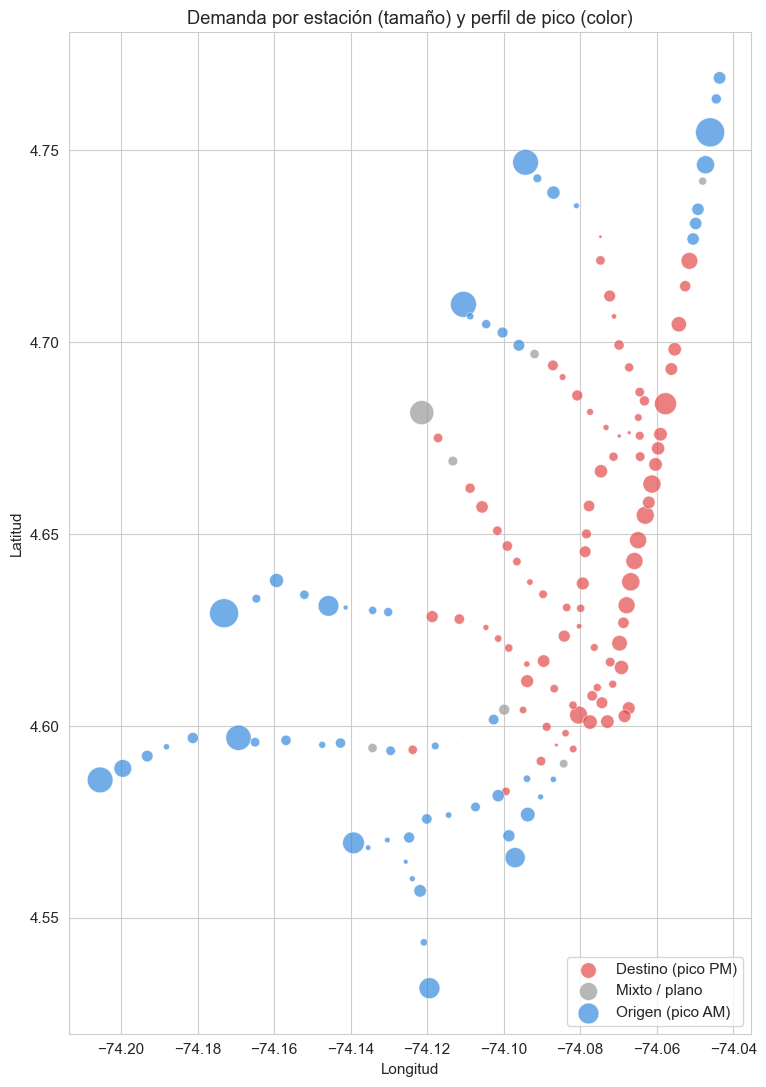

Mapa con 148 estaciones georreferenciadas.


In [74]:
# --- mapa geográfico: tamaño = demanda, color = perfil de pico ---
if {'lon', 'lat'}.issubset(est_attr.columns) and len(est_attr):
    mapa = est_attr.join(dem_est.rename('demanda')).join(perfil_pico['perfil'])
    mapa = mapa.dropna(subset=['lon', 'lat', 'demanda'])
    color_perfil = {'Origen (pico AM)':'#378ADD', 'Destino (pico PM)':'#E24B4A', 'Mixto / plano':'#999999'}
    fig, ax = plt.subplots(figsize=(9, 11))
    for perf, sub in mapa.groupby('perfil'):
        ax.scatter(sub['lon'], sub['lat'], s=sub['demanda'] / 2, alpha=.7,
                   color=color_perfil.get(perf, '#999999'), edgecolor='white', linewidth=.5, label=perf)
    ax.set_title('Demanda por estación (tamaño) y perfil de pico (color)')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud'); ax.legend(loc='lower right')
    ax.set_aspect(1 / np.cos(np.deg2rad(mapa['lat'].mean())))
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, 'fig_oe1_mapa_demanda.png'), dpi=150, bbox_inches='tight'); plt.show()
    print(f'Mapa con {len(mapa)} estaciones georreferenciadas.')
else:
    print('Sin coordenadas disponibles (revisar catálogo en data/soporte); se omite el mapa.')

## 9. Pruebas estadísticas (no paramétricas)

Confirman que los patrones observados son estadísticamente significativos y no producto del azar.

In [75]:
# ¿La demanda difiere por intervalo de 15 min del día?
grupos_int = [g['validaciones'].values for _, g in tipico.groupby('intervalo')]
h_stat, h_p = stats.kruskal(*grupos_int)
print(f"Kruskal-Wallis por INTERVALO de 15 min:  H={h_stat:,.0f}, p={h_p:.2e}")

# ¿Difiere entre día hábil y fin de semana?
hab_v = validaciones.loc[~validaciones['es_finde'], 'validaciones']
fds_v = validaciones.loc[validaciones['es_finde'], 'validaciones']
u_stat, u_p = stats.mannwhitneyu(hab_v, fds_v, alternative='two-sided')
print(f"Mann-Whitney hábil vs. fin de semana:  U={u_stat:,.0f}, p={u_p:.2e}")
print(f"   mediana hábil={hab_v.median():.1f} | mediana finde={fds_v.median():.1f}")

# ¿Difiere entre corredores?
if (tipico['corredor'] != 'Sin asignar').any():
    grupos_corr = [g['validaciones'].values for c, g in tipico.groupby('corredor') if c != 'Sin asignar']
    c_stat, c_p = stats.kruskal(*grupos_corr)
    print(f"Kruskal-Wallis por CORREDOR:  H={c_stat:,.0f}, p={c_p:.2e}")


Kruskal-Wallis por INTERVALO de 15 min:  H=2,230,475, p=0.00e+00
Mann-Whitney hábil vs. fin de semana:  U=8,374,429,612,054, p=0.00e+00
   mediana hábil=70.0 | mediana finde=37.0
Kruskal-Wallis por CORREDOR:  H=286,666, p=0.00e+00


**Interpretación.** Las tres pruebas rechazan la hipótesis nula (p < 0,05): la demanda **difiere significativamente** por hora del día, entre día hábil y fin de semana, y entre corredores. Los patrones descritos no son producto del azar, lo que valida construir indicadores y tipologías diferenciadas por estación y franja horaria.

## 10. Síntesis de OE1 — patrones espaciotemporales

Los resultados anteriores responden la dimensión de **patrones** de la pregunta de investigación:

- **Temporal:** demanda bimodal en día hábil (pico AM y pico PM) que se aplana los fines de semana. Entre meses, tanto la magnitud como la **forma** del perfil son estables: el receso escolar no reduce la demanda del troncal —sus usuarios son trabajadores, no estudiantes—, lo que se verificó empíricamente (diferencia de 0,6 p.p. en el pico AM). Por ello el análisis usa **todos los días hábiles no festivos**, sin excluir meses.
- **Espacial:** la demanda está fuertemente **concentrada** (Gini elevado; el 20% de las estaciones concentra la mayor parte) y difiere de forma significativa entre corredores (Kruskal-Wallis, p<0.05).
- **Espaciotemporal:** el mapa de calor y el mapa geográfico distinguen estaciones de **origen** (pico de mañana, periferia residencial) de estaciones de **destino** (pico de tarde, centro de empleo/servicios) — el patrón que el modelo de OE5 deberá anticipar.

- **Interanual:** la demanda total se contrae entre 2024 y 2025, con la caída concentrada en el **eje Caracas** por los cierres de la Primera Línea del Metro — el factor coyuntural señalado en el planteamiento del problema.

Estos patrones motivan los indicadores ICP/IPD (OE2–OE3) y la tipología de estaciones por conglomerados (OE4).